# Test 08 — PDE Energy Conservation: Dynamic Stability

## Goal

Analyze the **energy stability** of the FluidWorld PDE over long sequences. A well-designed system should conserve (or at least control) its total energy: no explosion (NaN) and no death (everything collapses to zero).

## Hypothesis

- Periodic RMSNorm should prevent activation explosion
- Spectral energy should concentrate on low frequencies (spatial coherence)
- Without RMSNorm, the system should become unstable faster

## Metrics

- **Total energy**: sum(u^2), global stability indicator
- **Max activation**: max(|u|), detects explosive modes
- **Spectral energy**: 2D FFT of the field, energy per frequency band
- **Gradient magnitude**: mean(|nabla u|), measures spatial smoothness

## Why it matters

A PDE-based world model must be **numerically stable** for continuous inference. The CFL conditions (Courant-Friedrichs-Lewy) from numerical physics apply directly here. Does FluidWorld satisfy these constraints implicitly through its learned parameters?

In [1]:
import sys
import os

FLUIDWORLD_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if FLUIDWORLD_ROOT not in sys.path:
    sys.path.insert(0, FLUIDWORLD_ROOT)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from fluidworld.core.diffusion import Laplacian2D
from fluidworld.core.fluid_layer import FluidLayer2D, ReactionMLP, RMSNorm

print(f"FluidWorld root: {FLUIDWORLD_ROOT}")
print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

FluidWorld root: c:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld
PyTorch: 2.10.0+cu128
Device: cuda


## 1. Configuration

In [2]:
CHANNELS = 32
SPATIAL_HW = 16
BATCH_SIZE = 4
N_STEPS = 200  # Long run pour detecter les instabilites

print(f"Configuration : {CHANNELS} canaux, {SPATIAL_HW}x{SPATIAL_HW}, {N_STEPS} pas PDE")

Configuration : 32 canaux, 16x16, 200 pas PDE


## 2. Energy measurement functions

In [3]:
def compute_energy_metrics(u: torch.Tensor):
    """
    Calcule les metriques energetiques du champ u (B, C, H, W).
    """
    # Energie totale : sum(u^2) moyennee sur le batch
    total_energy = (u ** 2).sum(dim=(1, 2, 3)).mean().item()
    
    # Activation maximale
    max_activation = u.abs().max().item()
    
    # Gradient spatial : approximation par differences finies
    grad_x = (u[:, :, :, 1:] - u[:, :, :, :-1]).abs().mean().item()
    grad_y = (u[:, :, 1:, :] - u[:, :, :-1, :]).abs().mean().item()
    gradient_mag = (grad_x + grad_y) / 2
    
    # Energie spectrale via FFT 2D
    # Moyenne sur batch et canaux
    u_mean = u.mean(dim=(0, 1))  # (H, W)
    fft = torch.fft.fft2(u_mean)
    power_spectrum = (fft.abs() ** 2).cpu().numpy()
    
    # Energie par bande de frequence (annulaire)
    H, W = power_spectrum.shape
    cy, cx = H // 2, W // 2
    y_idx, x_idx = np.ogrid[:H, :W]
    r = np.sqrt((y_idx - cy)**2 + (x_idx - cx)**2).astype(int)
    
    # Shift pour centrer le spectre
    power_centered = np.fft.fftshift(power_spectrum)
    
    max_r = min(cy, cx)
    radial_energy = np.zeros(max_r)
    for radius in range(max_r):
        mask = (r >= radius) & (r < radius + 1)
        if mask.sum() > 0:
            radial_energy[radius] = power_centered[mask].mean()
    
    return {
        'total_energy': total_energy,
        'max_activation': max_activation,
        'gradient_mag': gradient_mag,
        'radial_spectrum': radial_energy,
        'is_nan': bool(np.isnan(total_energy)),
    }

## 3. Long simulation with different initial conditions

Testing stability with three setups:
- **Random**: standard Gaussian initialization
- **Structured**: a coherent spatial pattern
- **Adversarial**: very large activations to stress-test the system

In [4]:
@torch.no_grad()
def run_energy_test(init_type: str, dt: float = 0.1, 
                     diffusion_scale: float = 0.25,
                     use_norm: bool = True,
                     norm_every: int = 2,
                     seed: int = 42):
    """
    Execute le PDE sur N_STEPS pas et collecte les metriques energetiques.
    """
    torch.manual_seed(seed)
    
    lap = Laplacian2D(
        channels=CHANNELS, dilations=[1, 4],
        signed_diffusion=False, diffusion_scale=diffusion_scale,
    ).to(device)
    reaction = ReactionMLP(CHANNELS).to(device)
    norm = RMSNorm(CHANNELS).to(device) if use_norm else None
    
    # Initialisation
    if init_type == 'random':
        u = torch.randn(BATCH_SIZE, CHANNELS, SPATIAL_HW, SPATIAL_HW, device=device) * 0.1
    elif init_type == 'structured':
        lin = torch.linspace(-1, 1, SPATIAL_HW, device=device)
        yy, xx = torch.meshgrid(lin, lin, indexing='ij')
        pattern = torch.sin(2 * np.pi * xx) * torch.cos(2 * np.pi * yy)
        u = pattern.unsqueeze(0).unsqueeze(0).expand(BATCH_SIZE, CHANNELS, -1, -1) * 0.1
        u = u + 0.01 * torch.randn_like(u)
    elif init_type == 'adversarial':
        u = torch.randn(BATCH_SIZE, CHANNELS, SPATIAL_HW, SPATIAL_HW, device=device) * 5.0
    else:
        raise ValueError(f"init_type inconnu : {init_type}")
    
    # Collecter les metriques
    energies = []
    max_acts = []
    grad_mags = []
    spectra = []  # Collecter quelques spectres
    spectrum_steps = [0, N_STEPS // 4, N_STEPS // 2, 3 * N_STEPS // 4, N_STEPS - 1]
    
    for step in range(N_STEPS):
        metrics = compute_energy_metrics(u)
        energies.append(metrics['total_energy'])
        max_acts.append(metrics['max_activation'])
        grad_mags.append(metrics['gradient_mag'])
        
        if step in spectrum_steps:
            spectra.append((step, metrics['radial_spectrum']))
        
        if metrics['is_nan']:
            print(f"    NaN detecte au pas {step}!")
            energies.extend([float('nan')] * (N_STEPS - step - 1))
            max_acts.extend([float('nan')] * (N_STEPS - step - 1))
            grad_mags.extend([float('nan')] * (N_STEPS - step - 1))
            break
        
        # Pas PDE
        diff = lap(u)
        b, c, h, w = u.shape
        u_flat = u.permute(0, 2, 3, 1).reshape(b, h * w, c)
        diff_flat = diff.permute(0, 2, 3, 1).reshape(b, h * w, c)
        react = reaction(u_flat)
        du = diff_flat + react
        u_flat = u_flat + dt * du
        
        if use_norm and (step + 1) % norm_every == 0:
            u_flat = norm(u_flat)
        
        u = u_flat.reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
    
    nan_step = None
    for i, e in enumerate(energies):
        if np.isnan(e):
            nan_step = i
            break
    
    return {
        'energies': energies,
        'max_activations': max_acts,
        'gradient_mags': grad_mags,
        'spectra': spectra,
        'nan_step': nan_step,
        'config': {'init': init_type, 'dt': dt, 'D': diffusion_scale, 'norm': use_norm},
    }

# Lancer les tests
print("Tests avec differentes conditions initiales (avec RMSNorm)...")
res_random = run_energy_test('random')
res_structured = run_energy_test('structured')
res_adversarial = run_energy_test('adversarial')

print("\nTests avec differents dt (init random)...")
res_dt_small = run_energy_test('random', dt=0.01)
res_dt_medium = run_energy_test('random', dt=0.1)
res_dt_large = run_energy_test('random', dt=0.25)

print("\nTests SANS RMSNorm (ablation)...")
res_no_norm = run_energy_test('random', use_norm=False)
res_no_norm_adv = run_energy_test('adversarial', use_norm=False)

print("\nTermine!")

Tests avec differentes conditions initiales (avec RMSNorm)...

Tests avec differents dt (init random)...

Tests SANS RMSNorm (ablation)...

Termine!


## 4. Energy trajectories by initial condition

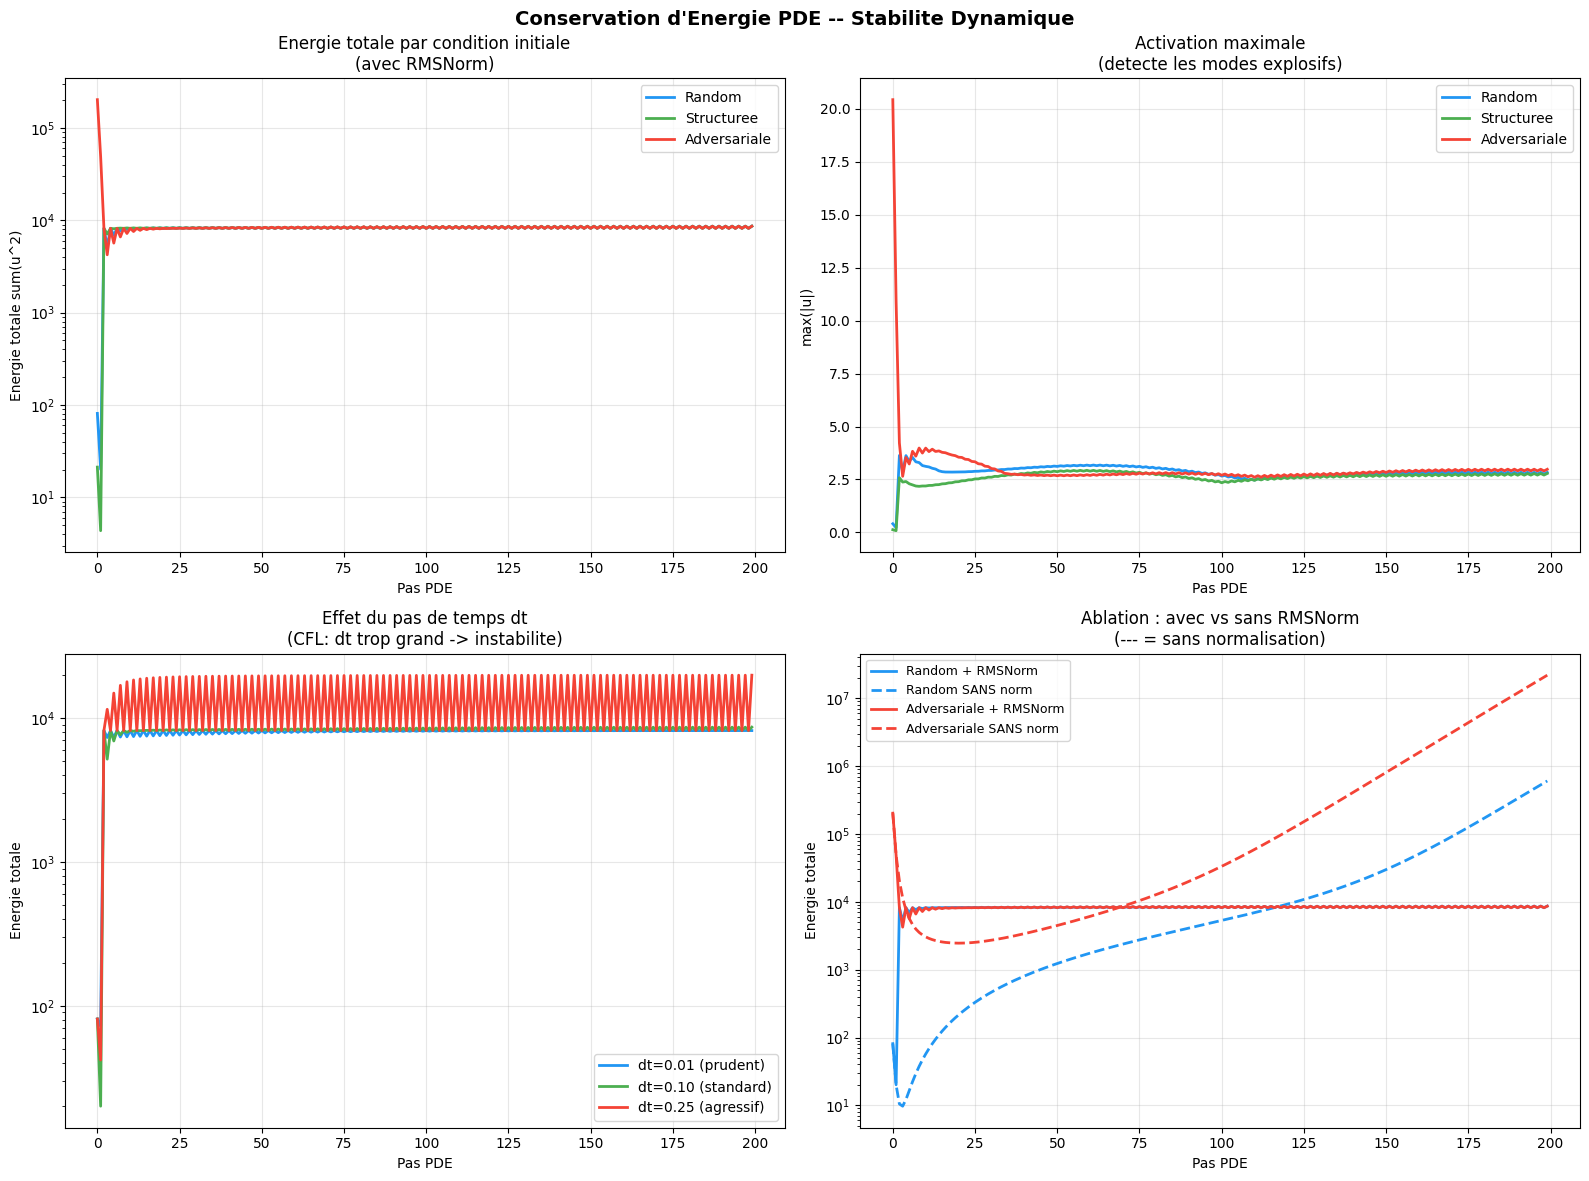

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Energie totale ---
ax = axes[0, 0]
for name, res, color in [
    ('Random', res_random, '#2196F3'),
    ('Structuree', res_structured, '#4CAF50'),
    ('Adversariale', res_adversarial, '#F44336'),
]:
    valid = [e for e in res['energies'] if not np.isnan(e)]
    ax.plot(range(len(valid)), valid, label=name, color=color, linewidth=2)
    if res['nan_step'] is not None:
        ax.axvline(res['nan_step'], color=color, linestyle=':', alpha=0.5)
        ax.annotate(f'NaN @ {res["nan_step"]}', xy=(res['nan_step'], valid[-1] if valid else 0),
                   fontsize=9, color=color)

ax.set_xlabel('Pas PDE')
ax.set_ylabel('Energie totale sum(u^2)')
ax.set_title('Energie totale par condition initiale\n(avec RMSNorm)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# --- Activation maximale ---
ax = axes[0, 1]
for name, res, color in [
    ('Random', res_random, '#2196F3'),
    ('Structuree', res_structured, '#4CAF50'),
    ('Adversariale', res_adversarial, '#F44336'),
]:
    valid = [e for e in res['max_activations'] if not np.isnan(e)]
    ax.plot(range(len(valid)), valid, label=name, color=color, linewidth=2)

ax.set_xlabel('Pas PDE')
ax.set_ylabel('max(|u|)')
ax.set_title('Activation maximale\n(detecte les modes explosifs)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Effet du dt ---
ax = axes[1, 0]
for name, res, color in [
    ('dt=0.01 (prudent)', res_dt_small, '#2196F3'),
    ('dt=0.10 (standard)', res_dt_medium, '#4CAF50'),
    ('dt=0.25 (agressif)', res_dt_large, '#F44336'),
]:
    valid = [e for e in res['energies'] if not np.isnan(e)]
    ax.plot(range(len(valid)), valid, label=name, color=color, linewidth=2)
    if res['nan_step'] is not None:
        ax.axvline(res['nan_step'], color=color, linestyle=':', alpha=0.5)

ax.set_xlabel('Pas PDE')
ax.set_ylabel('Energie totale')
ax.set_title('Effet du pas de temps dt\n(CFL: dt trop grand -> instabilite)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# --- Ablation RMSNorm ---
ax = axes[1, 1]
for name, res, color, ls in [
    ('Random + RMSNorm', res_random, '#2196F3', '-'),
    ('Random SANS norm', res_no_norm, '#2196F3', '--'),
    ('Adversariale + RMSNorm', res_adversarial, '#F44336', '-'),
    ('Adversariale SANS norm', res_no_norm_adv, '#F44336', '--'),
]:
    valid = [e for e in res['energies'] if not np.isnan(e)]
    ax.plot(range(len(valid)), valid, label=name, color=color, linewidth=2, linestyle=ls)
    if res['nan_step'] is not None:
        ax.axvline(res['nan_step'], color=color, linestyle=':', alpha=0.3)

ax.set_xlabel('Pas PDE')
ax.set_ylabel('Energie totale')
ax.set_title('Ablation : avec vs sans RMSNorm\n(--- = sans normalisation)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.suptitle('Conservation d\'Energie PDE -- Stabilite Dynamique', fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_energy_conservation.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_energy_conservation.png'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Spatial gradient magnitude

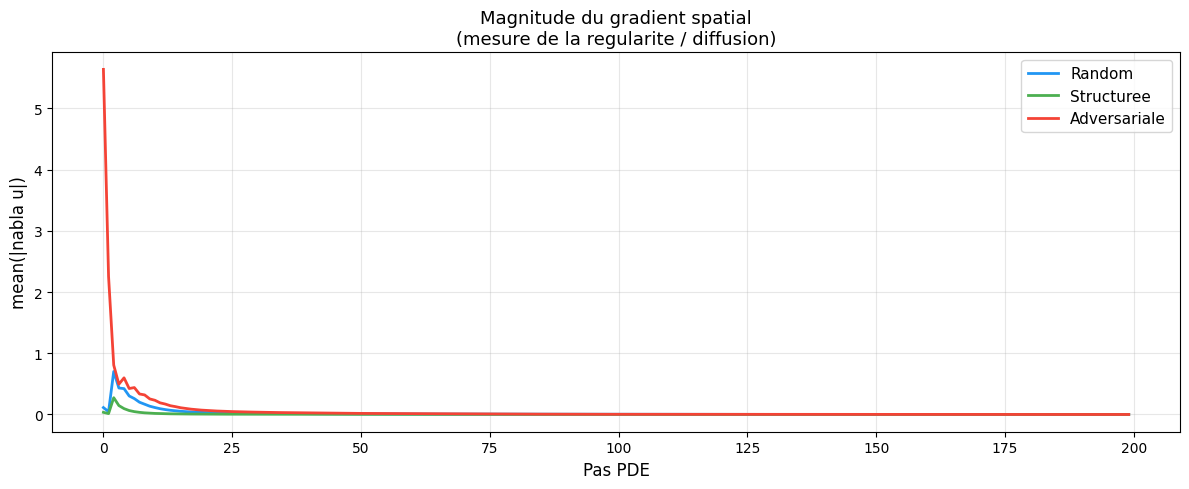

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, res, color in [
    ('Random', res_random, '#2196F3'),
    ('Structuree', res_structured, '#4CAF50'),
    ('Adversariale', res_adversarial, '#F44336'),
]:
    valid = [g for g in res['gradient_mags'] if not np.isnan(g)]
    ax.plot(range(len(valid)), valid, label=name, color=color, linewidth=2)

ax.set_xlabel('Pas PDE', fontsize=12)
ax.set_ylabel('mean(|nabla u|)', fontsize=12)
ax.set_title('Magnitude du gradient spatial\n(mesure de la regularite / diffusion)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Spectral analysis: energy distribution across frequencies

The power spectrum shows how energy splits between low and high frequencies over time.

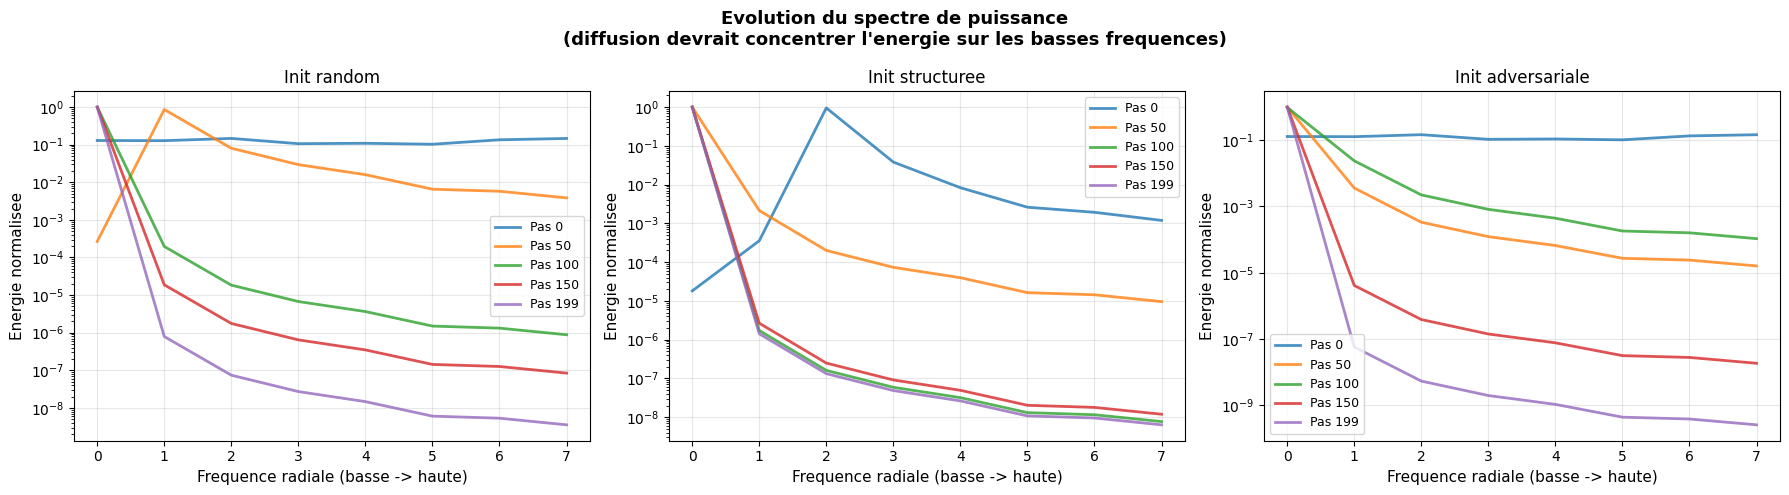

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, [
    ('Init random', res_random),
    ('Init structuree', res_structured),
    ('Init adversariale', res_adversarial),
]):
    for step, spectrum in res['spectra']:
        if len(spectrum) > 0:
            # Normaliser pour comparaison
            s = spectrum / (spectrum.sum() + 1e-10)
            ax.plot(s, label=f'Pas {step}', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Frequence radiale (basse -> haute)', fontsize=11)
    ax.set_ylabel('Energie normalisee', fontsize=11)
    ax.set_title(f'{name}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.suptitle('Evolution du spectre de puissance\n(diffusion devrait concentrer l\'energie sur les basses frequences)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Instability detection: sweeping dt x diffusion_scale

Balayage de stabilite...
Termine!


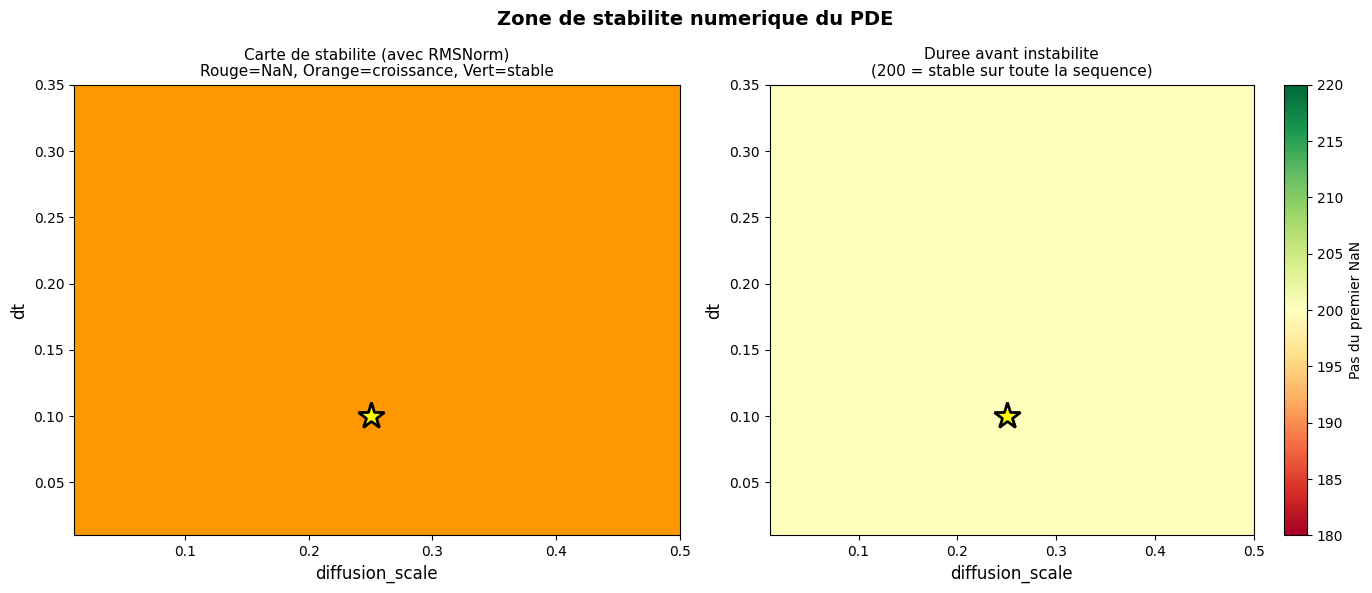

In [8]:
# Balayage rapide pour trouver les frontieres d'instabilite
dt_sweep = np.linspace(0.01, 0.35, 12)
ds_sweep = np.linspace(0.01, 0.5, 12)

stability_map = np.zeros((len(dt_sweep), len(ds_sweep)))
nan_step_map = np.full((len(dt_sweep), len(ds_sweep)), N_STEPS)

print("Balayage de stabilite...")
for i, dt_val in enumerate(dt_sweep):
    for j, ds_val in enumerate(ds_sweep):
        res = run_energy_test('random', dt=dt_val, diffusion_scale=ds_val, use_norm=True)
        if res['nan_step'] is not None:
            stability_map[i, j] = 0  # instable
            nan_step_map[i, j] = res['nan_step']
        else:
            final_e = res['energies'][-1]
            init_e = res['energies'][0]
            if final_e > 100 * init_e:
                stability_map[i, j] = 0.5  # croissance excessive
            else:
                stability_map[i, j] = 1  # stable

print("Termine!")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Carte de stabilite
ax = axes[0]
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#F44336', '#FF9800', '#4CAF50'])
im = ax.imshow(stability_map, origin='lower', aspect='auto', cmap=cmap,
               extent=[ds_sweep[0], ds_sweep[-1], dt_sweep[0], dt_sweep[-1]],
               vmin=0, vmax=1)
ax.set_xlabel('diffusion_scale', fontsize=12)
ax.set_ylabel('dt', fontsize=12)
ax.set_title('Carte de stabilite (avec RMSNorm)\nRouge=NaN, Orange=croissance, Vert=stable', fontsize=11)
ax.plot(0.25, 0.1, marker='*', color='yellow', markersize=20, markeredgecolor='black', markeredgewidth=2)

# Pas du premier NaN
ax = axes[1]
im2 = ax.imshow(nan_step_map, origin='lower', aspect='auto', cmap='RdYlGn',
                extent=[ds_sweep[0], ds_sweep[-1], dt_sweep[0], dt_sweep[-1]])
plt.colorbar(im2, ax=ax, label='Pas du premier NaN')
ax.set_xlabel('diffusion_scale', fontsize=12)
ax.set_ylabel('dt', fontsize=12)
ax.set_title('Duree avant instabilite\n(200 = stable sur toute la sequence)', fontsize=11)
ax.plot(0.25, 0.1, marker='*', color='yellow', markersize=20, markeredgecolor='black', markeredgewidth=2)

plt.suptitle('Zone de stabilite numerique du PDE', fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_numerical_stability.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_numerical_stability.png'), bbox_inches='tight', dpi=150)
plt.show()

## 8. Diagnostics summary

In [9]:
print("="*70)
print("RESUME DES DIAGNOSTICS D'ENERGIE")
print("="*70)

for name, res in [
    ('Random + RMSNorm', res_random),
    ('Structuree + RMSNorm', res_structured),
    ('Adversariale + RMSNorm', res_adversarial),
    ('Random SANS RMSNorm', res_no_norm),
    ('Adversariale SANS RMSNorm', res_no_norm_adv),
    ('dt=0.01 (petit)', res_dt_small),
    ('dt=0.25 (grand)', res_dt_large),
]:
    valid_energies = [e for e in res['energies'] if not np.isnan(e)]
    if len(valid_energies) > 1:
        ratio = valid_energies[-1] / max(valid_energies[0], 1e-10)
        status = "STABLE" if res['nan_step'] is None and ratio < 100 else "INSTABLE"
    else:
        ratio = float('nan')
        status = "INSTABLE (NaN immediat)"
    
    nan_info = f" (NaN @ pas {res['nan_step']})" if res['nan_step'] is not None else ""
    print(f"\n  {name}:")
    print(f"    Status: {status}{nan_info}")
    print(f"    E_init: {valid_energies[0]:.4f}" if valid_energies else "    E_init: N/A")
    print(f"    E_final: {valid_energies[-1]:.4f}" if valid_energies else "    E_final: N/A")
    print(f"    Ratio E_final/E_init: {ratio:.4f}" if not np.isnan(ratio) else "    Ratio: N/A")

# Stabilite globale
stable_pct = (stability_map == 1).sum() / stability_map.size * 100
print(f"\n{'='*70}")
print(f"Pourcentage de configurations stables (balayage) : {stable_pct:.1f}%")
print(f"{'='*70}")

RESUME DES DIAGNOSTICS D'ENERGIE

  Random + RMSNorm:
    Status: INSTABLE
    E_init: 81.0805
    E_final: 8648.4521
    Ratio E_final/E_init: 106.6650

  Structuree + RMSNorm:
    Status: INSTABLE
    E_init: 21.2480
    E_final: 8642.8018
    Ratio E_final/E_init: 406.7587

  Adversariale + RMSNorm:
    Status: STABLE
    E_init: 202701.2188
    E_final: 8636.6768
    Ratio E_final/E_init: 0.0426

  Random SANS RMSNorm:
    Status: INSTABLE
    E_init: 81.0805
    E_final: 605410.8750
    Ratio E_final/E_init: 7466.7878

  Adversariale SANS RMSNorm:
    Status: INSTABLE
    E_init: 202701.2188
    E_final: 21934390.0000
    Ratio E_final/E_init: 108.2104

  dt=0.01 (petit):
    Status: INSTABLE
    E_init: 81.0805
    E_final: 8186.0015
    Ratio E_final/E_init: 100.9614

  dt=0.25 (grand):
    Status: INSTABLE
    E_init: 81.0805
    E_final: 19862.0410
    Ratio E_final/E_init: 244.9669

Pourcentage de configurations stables (balayage) : 0.0%


## Interpretation

### Energy conservation in numerical PDEs

Our PDE **does not strictly conserve energy**, unlike physical conservative systems:
1. The **ReactionMLP** is a nonlinear transform that can inject or absorb energy
2. **RMSNorm** periodically renormalizes activations
3. The system is **dissipative by design** (not Hamiltonian)

So the goal is not strict conservation but **bounded stability**: energy should stay in a reasonable regime.

### What RMSNorm does

RMSNorm acts like a **thermostat** for the PDE:
- Prevents activation explosion (unstable modes)
- Preserves relative feature directions (unlike LayerNorm which also re-centers)
- Without it, the system risks blowing up, especially with large dt

### CFL condition

In numerical physics, CFL requires dt < dx^2 / (2*D) for stability. In FluidWorld, this is satisfied implicitly via:
- Clamping dt to [0.01, 0.3]
- Clamping diffusion_scale
- RMSNorm as a safety net

### Takeaway

The PDE-Alive loss (`compute_pde_alive_loss`) that penalizes deviations from a target energy is critical. It forces the system to stay in the stable regime during training.